<a href="https://colab.research.google.com/github/sanjayk16-07/AI-Student-Dataset/blob/main/AI_Student_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AI Student data Classifications and Regression

In [1]:
from google.colab import files
uploaded = files.upload()

Saving ai_student_impact_dataset (1).csv to ai_student_impact_dataset (1).csv


In [2]:
import pandas as pd

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print(df.shape)

df.head()

(50000, 16)


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [3]:
!pip install scikit-learn

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

target = "Burnout_Risk_Level"

X = df.drop(columns=[target])

y = LabelEncoder().fit_transform(df[target])

cat_cols = X.select_dtypes(include="object").columns

num_cols = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer([
(
"cat",
Pipeline([
("fill", SimpleImputer(strategy="most_frequent")),
("encode", OneHotEncoder(handle_unknown="ignore"))
]),
cat_cols
),

(
"num",
Pipeline([
("fill", SimpleImputer(strategy="median")),
("scale", StandardScaler())
]),
num_cols
)

])

X = preprocessor.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

print(X_train.shape)

(40000, 31)


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pandas as pd

models = {

"Logistic Regression":
LogisticRegression(max_iter=3000),

"Decision Tree":
DecisionTreeClassifier(),

"Random Forest":
RandomForestClassifier(n_estimators=200),

"KNN":
KNeighborsClassifier(),

"Naive Bayes":
GaussianNB(),

"SVM":
SVC()

}

results = []

for name, model in models.items():

    if name == "Naive Bayes":

        model.fit(X_train, y_train)

        pred = model.predict(
            X_test
        )

    else:

        model.fit(
            X_train,
            y_train
        )

        pred = model.predict(
            X_test
        )

    acc = accuracy_score(
        y_test,
        pred
    )

    results.append(
        [name, acc]
    )

    print(
        f"{name}: {acc:.4f}"
    )

result_df = pd.DataFrame(
results,
columns=[
"Model",
"Accuracy"
]
)

result_df = result_df.sort_values(
by="Accuracy",
ascending=False
)

print("\n===== FINAL RESULT =====\n")

print(result_df)

print(
"\nBest Model:"
)

print(
result_df.iloc[0]
)

Logistic Regression: 0.5391
Decision Tree: 0.4344
Random Forest: 0.5266
KNN: 0.4549
Naive Bayes: 0.5202
SVM: 0.5300

===== FINAL RESULT =====

                 Model  Accuracy
0  Logistic Regression    0.5391
5                  SVM    0.5300
2        Random Forest    0.5266
4          Naive Bayes    0.5202
3                  KNN    0.4549
1        Decision Tree    0.4344

Best Model:
Model       Logistic Regression
Accuracy                 0.5391
Name: 0, dtype: object


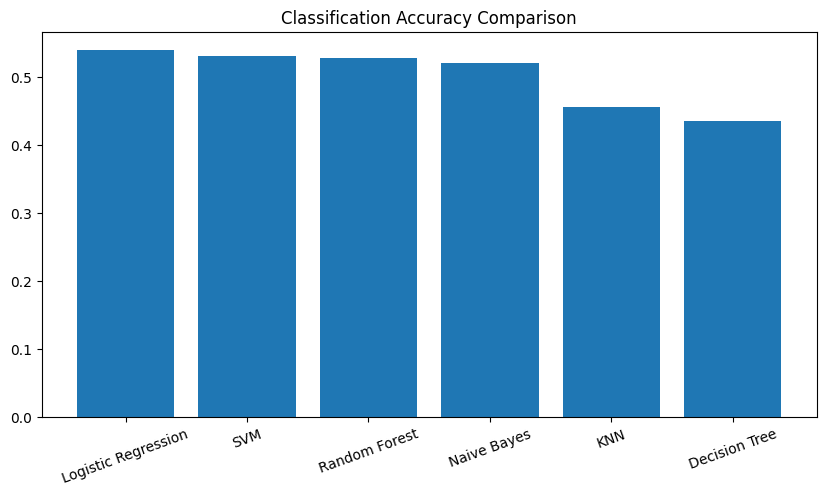

In [6]:
import matplotlib.pyplot as plt

plt.figure(
figsize=(10,5)
)

plt.bar(
result_df["Model"],
result_df["Accuracy"]
)

plt.xticks(
rotation=20
)

plt.title(
"Classification Accuracy Comparison"
)

plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
LinearRegression,
Ridge,
Lasso
)

from sklearn.preprocessing import PolynomialFeatures

from sklearn.svm import SVR

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
r2_score,
mean_absolute_error
)

import pandas as pd
import numpy as np

In [8]:
from sklearn.preprocessing import LabelEncoder

target="Burnout_Risk_Level"

X=df.drop(columns=[target])

y=df[target]

# Convert Low Medium High → 0 1 2
encoder=LabelEncoder()

y=encoder.fit_transform(y)

cat_cols=X.select_dtypes(include="object").columns

num_cols=X.select_dtypes(exclude="object").columns

preprocessor=ColumnTransformer([

(
"cat",

Pipeline([

(
"fill",

SimpleImputer(
strategy="most_frequent"
)
),

(
"onehot",

OneHotEncoder(
handle_unknown="ignore"
)
)

]),

cat_cols
),

(
"num",

Pipeline([

(
"fill",

SimpleImputer(
strategy="median"
)
),

(
"scale",

StandardScaler()
)

]),

num_cols
)

])

X=preprocessor.fit_transform(X)

if hasattr(X,"toarray"):
    X=X.toarray()

X_train,X_test,y_train,y_test=(

train_test_split(

X,

y,

test_size=0.2,

random_state=42

)

)

print(X_train.shape)

(40000, 31)


In [9]:
results=[]

models={

"Simple Linear":
LinearRegression(),

"Multiple Linear":
LinearRegression(),

"Polynomial":
None,

"Ridge":
Ridge(),

"Lasso":
Lasso(),

"SVR":
SVR(),

"Decision Tree":
DecisionTreeRegressor(),

"Random Forest":
RandomForestRegressor(
n_estimators=200
)

}

for name,model in models.items():

    if name=="Polynomial":

        poly=PolynomialFeatures(
            degree=2
        )

        X_train_poly=poly.fit_transform(
            X_train
        )

        X_test_poly=poly.transform(
            X_test
        )

        reg=LinearRegression()

        reg.fit(
            X_train_poly,
            y_train
        )

        pred=reg.predict(
            X_test_poly
        )

    else:

        model.fit(
            X_train,
            y_train
        )

        pred=model.predict(
            X_test
        )

    r2=r2_score(
        y_test,
        pred
    )

    mae=mean_absolute_error(
        y_test,
        pred
    )

    results.append(
        [
        name,
        r2,
        mae
        ]
    )

    print(
f"{name} → R²={r2:.4f}"
)

result_df=pd.DataFrame(

results,

columns=[
"Model",
"R2",
"MAE"
]

)

result_df=result_df.sort_values(

by="R2",

ascending=False

)

print()

print(result_df)

print()

print(
"Best Regression Model:"
)

print(
result_df.iloc[0]
)

Simple Linear → R²=0.1227
Multiple Linear → R²=0.1227
Polynomial → R²=0.1268
Ridge → R²=0.1227
Lasso → R²=-0.0001
SVR → R²=0.0584
Decision Tree → R²=-0.7496
Random Forest → R²=0.1223

             Model        R2       MAE
2       Polynomial  0.126771  0.665444
0    Simple Linear  0.122747  0.672277
1  Multiple Linear  0.122747  0.672277
3            Ridge  0.122747  0.672278
7    Random Forest  0.122266  0.658695
5              SVR  0.058380  0.643828
4            Lasso -0.000127  0.701267
6    Decision Tree -0.749597  0.755300

Best Regression Model:
Model    Polynomial
R2         0.126771
MAE        0.665444
Name: 2, dtype: object


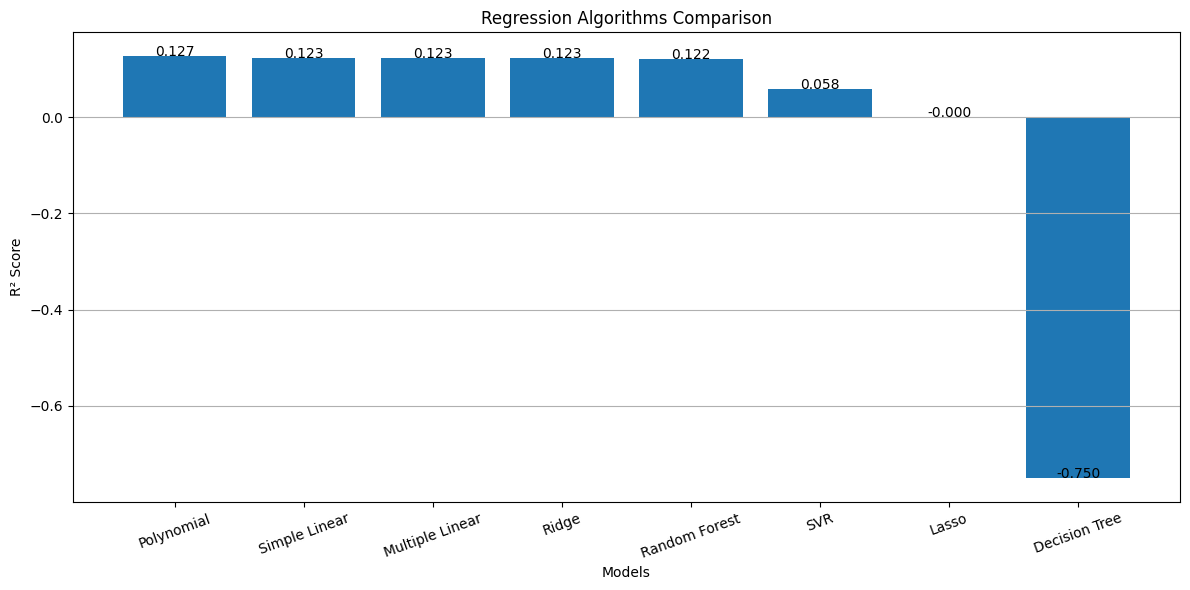


Best Model:
Model    Polynomial
R2         0.126771
MAE        0.665444
Name: 2, dtype: object


In [10]:
import matplotlib.pyplot as plt

plot_df = result_df.sort_values(
    by="R2",
    ascending=False
)

plt.figure(figsize=(12,6))

bars = plt.bar(
    plot_df["Model"],
    plot_df["R2"]
)

# Zoom graph for small values
plt.ylim(
    min(plot_df["R2"]) - 0.05,
    max(plot_df["R2"]) + 0.05
)

for bar in bars:

    h = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        h,
        f"{h:.3f}",
        ha="center"
    )

plt.title(
    "Regression Algorithms Comparison"
)

plt.xlabel(
    "Models"
)

plt.ylabel(
    "R² Score"
)

plt.xticks(
    rotation=20
)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

print("\nBest Model:")
print(plot_df.iloc[0])